In [2]:
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass
import pickle
import time
from typing import Optional

In [3]:
def plot_st(st_matrix, f, title="Stockwell Transform"):
    plt.figure(figsize=(12, 8))

    extent = [0, st_matrix.shape[1], 0, f]

    plt.imshow(
        np.abs(st_matrix),
        extent=extent,
        aspect='auto',
        origin='lower',
        cmap='viridis'
    )

    plt.colorbar(label="Magnitude")
    plt.xlabel("Time")
    plt.ylabel("Frequency")

    plt.yscale("log")
    plt.ylim(max(0.05, 0), f)

    plt.title(title)
    plt.tight_layout()
    plt.show()


def stockwell(
    x: np.ndarray,
    dt: float,
    kmin: int = 0,
    kmax: Optional[int] = None,
    kstep: int = 1,
    chunk_size: int = 256,
    mmap_path: Optional[str] = None,
):
    real = np.float16
    out_dtype = np.complex64

    x = np.asarray(x, dtype=real)
    n = x.size

    if kmax is None:
        kmax = n // 2

    k_bins = np.arange(kmin, kmax + 1, kstep, dtype=int)
    num_k  = k_bins.size

    if mmap_path is None:
        S = np.zeros((num_k, n), dtype=out_dtype)
    else:
        S = np.memmap(mmap_path, mode="w+", dtype=out_dtype, shape=(num_k, n))

    row_cursor = (kmin==0)
    if kmin == 0:
        S[0, :] = np.mean(x).astype(real)
        k_bins = k_bins[1:]
        num_k-=1

    X = np.fft.fft(x)
    X2 = np.concatenate([X, X])

    t_front = np.arange(n, dtype=np.float32)**2
    t_back  = np.arange(-n, 0, dtype=np.float32)**2

    cols = np.arange(n)

    for i in range(0, num_k, chunk_size):

        k_batch = k_bins[i : i + chunk_size]
        B = k_batch.size
        if B == 0:
            break

        scale = -2.0 * (np.pi ** 2)
        scale = np.float16(scale) / (k_batch.astype(np.float32) ** 2)

        s = scale[:, None]

        gauss = np.exp(s * t_front[None, :], dtype=np.float32) + np.exp(s * t_back[None, :], dtype=np.float32)

        idx_start = k_batch[:, None] + cols[None, :]
        slices = X2[idx_start]

        rows = np.fft.ifft(slices * gauss, axis=1)

        S[row_cursor:row_cursor + B, :] = rows.astype(out_dtype, copy=False)
        row_cursor += B

    f_hz = kmax / (n * dt)

    return S, f_hz


In [4]:
@dataclass
class StationTF:

    HVSRN: np.ndarray | None
    HVSRE: np.ndarray | None

    fullHVSRN: np.ndarray | None
    fullHVSRE: np.ndarray | None

In [5]:
with open("sel.pkl", "rb") as f:
    sel_N, sel_E, sel_Z = pickle.load(f)

waveforms_N_data = [xt.data for xt in sel_N]
waveforms_E_data = [xt.data for xt in sel_E]
waveforms_Z_data = [xt.data for xt in sel_Z]

waveforms_N_delta = [st.stats.delta for st in sel_N]
waveforms_E_delta = [st.stats.delta for st in sel_E]
waveforms_Z_delta = [st.stats.delta for st in sel_Z]

In [6]:
x = waveforms_E_data[0]
dt = waveforms_E_delta[0]

"""
from scipy.signal import decimate
x = decimate(x, 2, ftype="fir", zero_phase=True)
dt = dt * 2
"""

'\nfrom scipy.signal import decimate\nx = decimate(x, 2, ftype="fir", zero_phase=True)\ndt = dt * 2\n'

In [ ]:
st_matrix_E, k = stockwell(x,dt, kmin=0, kmax=len(waveforms_E_data[0])//2, kstep=4, chunk_size=500)

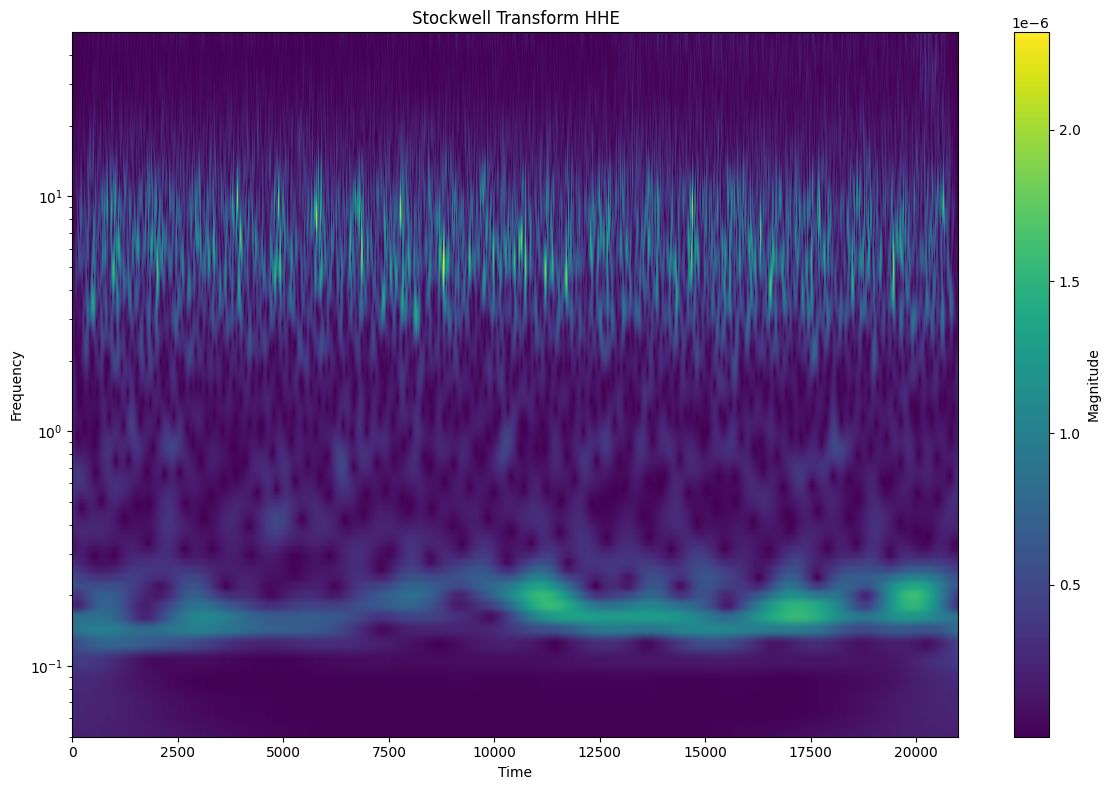

In [12]:
plot_st(st_matrix_E, k, title="Stockwell Transform HHE")

In [77]:
with open("results.pkl", "wb") as f:
    pickle.dump(res, f)